In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [28]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

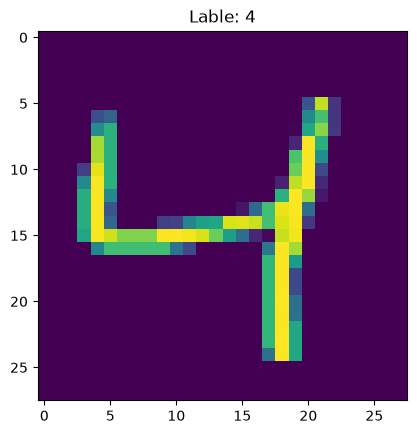

In [29]:
sample = 2
plt.imshow(x_train[sample])
plt.title(f"Lable: {y_train[sample]}")
plt.show()

In [30]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [41]:
x_train_small = (x_train[:5000] / 255.0).astype("float32")
y_train_small = y_train[:5000]
x_test = (x_test / 255.0).astype("float32")

In [32]:
train_set = tf.data.Dataset.from_tensor_slices((x_train_small, y_train_small)).shuffle(buffer_size=5000).batch(128)
test_set = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32)

In [33]:
for images, lables in train_set.take(1):
    print("Image Shape:", images.shape)
    print("Lable Shape:", lables.shape)

Image Shape: (128, 28, 28, 1)
Lable Shape: (128,)


In [34]:
inputs = tf.keras.layers.Input(shape=(28, 28, 1))
x = tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(inputs)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
outputs = tf.keras.layers.Dense(10)(x)

In [35]:
model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name="My_Model")

In [36]:
model.summary()

Model: "My_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

In [38]:
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        predictions = model(images)
        loss = loss_fn(labels, predictions)
    sources = model.trainable_variables
    gradient = tape.gradient(loss, sources)

    optimizer.apply_gradients(zip(gradient, sources))

    return loss

In [39]:
EPOCHS = 2
for epoch in range(EPOCHS):
    print(f"\n--- شروع دور (Epoch) شماره {epoch + 1} ---")
    
    for step, (images, labels) in enumerate(train_set):
        loss_value = train_step(images, labels)

        if step % 50 == 0 :
            print(f"گام {step}: خطا (Loss) = {loss_value.numpy():.4f}")


--- شروع دور (Epoch) شماره 1 ---
گام 0: خطا (Loss) = 2.3047

--- شروع دور (Epoch) شماره 2 ---
گام 0: خطا (Loss) = 0.4830


In [45]:
# test
test_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

In [46]:
for images, labels in test_set:
    predictions = model(images)
    test_acc_metric.update_state(labels, predictions)
print(f"Test Accuracy: {test_acc_metric.result().numpy() * 100:.2f}%")

Test Accuracy: 89.59%


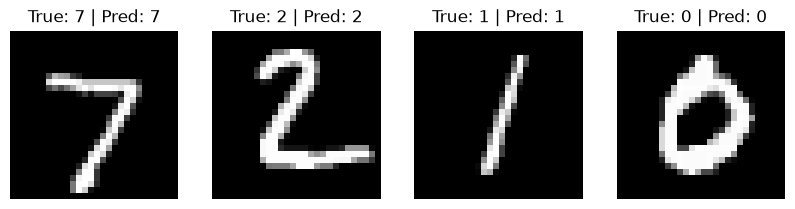

In [47]:
import numpy as np

# گرفتن یک دسته تست و پیش‌بینی
for test_images, test_labels in test_set.take(1):
    preds = model(test_images)
    pred_labels = tf.argmax(preds, axis=1)

# نمایش ۴ تصویر اول همراه با پیش‌بینی
plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(test_images[i].numpy().squeeze(), cmap="gray")
    plt.title(f"True: {test_labels[i]} | Pred: {pred_labels[i].numpy()}")
    plt.axis("off")
plt.show()